<a href="https://colab.research.google.com/github/Sudipa2005/shopping-behaviour-analysis/blob/main/shopping_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('/content/shopping_behavior.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [6]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [7]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

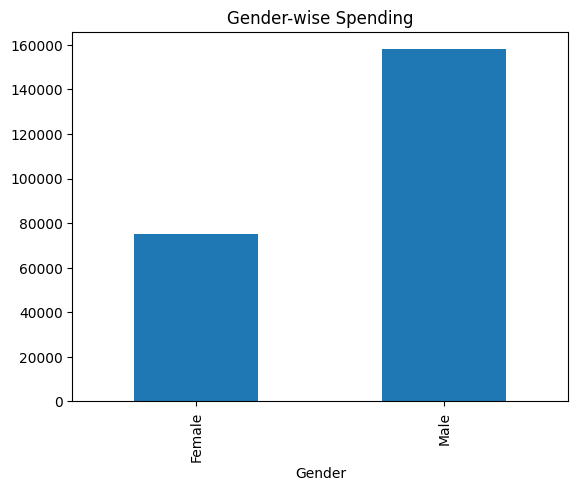

In [8]:
gender_spend = df.groupby('Gender')['Purchase Amount (USD)'].sum()
gender_spend.plot(kind='bar', title='Gender-wise Spending')
plt.show()

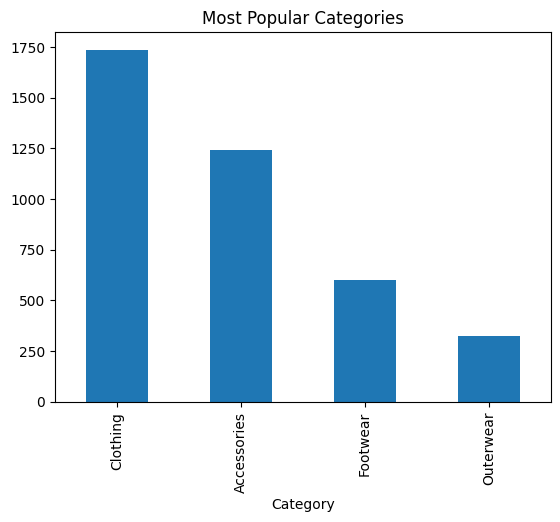

In [9]:
category_sales = df['Category'].value_counts()
category_sales.plot(kind='bar', title='Most Popular Categories')
plt.show()

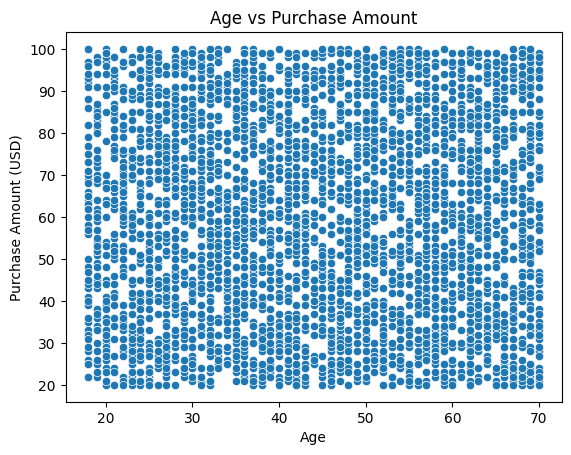

In [10]:
sns.scatterplot(x='Age', y='Purchase Amount (USD)', data=df)
plt.title('Age vs Purchase Amount')
plt.show()

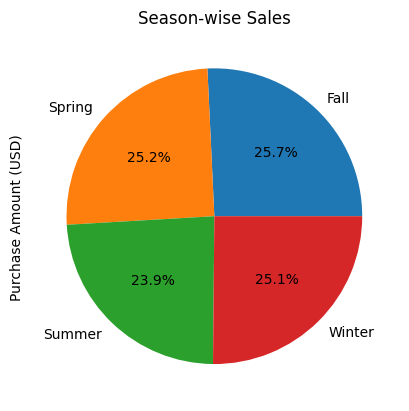

In [11]:
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum()
season_sales.plot(kind='pie', autopct='%1.1f%%', title='Season-wise Sales')
plt.show()

In [12]:
top_customers = df.sort_values(by='Purchase Amount (USD)', ascending=False).head(10)
top_customers[['Customer ID', 'Purchase Amount (USD)']]

,Customer ID,Purchase Amount (USD)
1479,1480,100
1456,1457,100
1591,1592,100
2071,2072,100
1421,1422,100
1412,1413,100
1405,1406,100
1847,1848,100
769,770,100
2842,2843,100


In [13]:
import sqlite3

conn = sqlite3.connect('shopping.db')
df.to_sql('shopping', conn, if_exists='replace', index=False)

3900

In [14]:
query = """
SELECT Gender, SUM(`Purchase Amount (USD)`) AS Total_Spending
FROM shopping
GROUP BY Gender
"""
pd.read_sql(query, conn)

,Gender,Total_Spending
0,Female,75191
1,Male,157890


In [15]:
query = """
SELECT Category, COUNT(*) AS Purchase_Count
FROM shopping
GROUP BY Category
ORDER BY Purchase_Count DESC
"""
pd.read_sql(query, conn)

,Category,Purchase_Count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [16]:
query = """
SELECT Age, AVG(`Purchase Amount (USD)`) AS Avg_Spending
FROM shopping
GROUP BY Age
ORDER BY Avg_Spending DESC
"""
pd.read_sql(query, conn)

,Age,Avg_Spending
0,53,67.885714
1,49,66.095238
2,44,64.941176
3,28,64.607595
4,61,64.184615
5,21,64.101449
6,51,63.902778
7,65,63.750000
8,54,63.638554
9,25,63.200000


In [17]:
query = """
SELECT `Customer ID`, SUM(`Purchase Amount (USD)`) AS Total_Spent
FROM shopping
GROUP BY `Customer ID`
ORDER BY Total_Spent DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Customer ID,Total_Spent
0,3838,100
1,3726,100
2,3322,100
3,3266,100
4,3029,100


In [18]:
df.to_csv("cleaned_shopping_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_shopping_data.csv")